In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [5]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,))
    ]
)

In [6]:
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 34.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 895kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 6.75MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.97MB/s]


In [7]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)

In [9]:
train_loader

In [8]:
import matplotlib.pyplot as plt
images, labels = next(iter(train_loader))

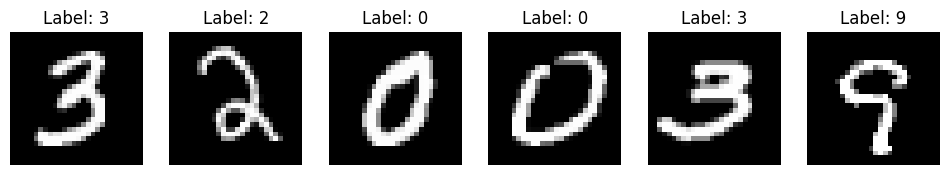

In [12]:
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    axes[i].imshow(images[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis("off")
plt.show()

In [13]:
import torch.nn as nn

# ------ Teacher Model (2 hidden layers) ------
class TeacherMLP(nn.Module):
    def __init__(self, hidden1=512, hidden2=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 10)  # 10 output classes (digits)
        )

    def forward(self, x):
        return self.net(x)


In [14]:
teacher = TeacherMLP()

In [15]:
print(teacher)

TeacherMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [16]:
teacher.parameters()

<generator object Module.parameters at 0x791328c72880>

In [17]:
# ----- Train Teacher -----
def train_teacher(model, loader, epochs=3, lr=1e-3):

    opt = optim.Adam(model.parameters(), lr=lr)

    loss_fn = nn.CrossEntropyLoss()

    model.train()

    for ep in range(epochs):
        total_loss = 0
        for x, y in loader:
            opt.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            opt.step()
            total_loss += loss.item()
        print(f"Teacher Epoch {ep+1}: Loss = {total_loss/len(loader):.4f}")


In [18]:
train_teacher(teacher, train_loader)

Teacher Epoch 1: Loss = 0.2974
Teacher Epoch 2: Loss = 0.1357
Teacher Epoch 3: Loss = 0.0996


In [ ]:
teacher.state_dict()

In [21]:
# ------ Student Model (1 hidden layer) -----
class StudentMLP(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 10)  # smaller model, only 1 hidden layer
        )

    def forward(self, x):
        return self.net(x)

student = StudentMLP(hidden=128)

print(student)


StudentMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [22]:
# (A) Pretrain student on hard labels (optional warm-up)
def pretrain_student(student, loader, epochs=1, lr=1e-3):
    student.train()
    opt = optim.Adam(student.parameters(), lr=lr)
    ce_loss = nn.CrossEntropyLoss()
    for ep in range(epochs):
        for x, y in loader:
            opt.zero_grad()
            out = student(x)
            loss = ce_loss(out, y)
            loss.backward()
            opt.step()



In [ ]:
pretrain_student(student, train_loader, epochs=1)  # optional warm-up


In [23]:
# ----- Distillation Training -----
temperature = 2.0
alpha = 0.7
ce_loss = nn.CrossEntropyLoss()
kl_loss = nn.KLDivLoss(reduction="batchmean")
optimizer = optim.Adam(student.parameters(), lr=1e-3)


In [24]:
def distill(student, teacher, loader, epochs=3):
    for ep in range(epochs):
        student.train()
        total_loss = 0
        for x, y in loader:
            # Teacher outputs
            with torch.no_grad():
                t_logits = teacher(x)
                t_probs = torch.softmax(t_logits / temperature, dim=1)

            # Student outputs
            s_logits = student(x)
            s_log_probs = torch.log_softmax(s_logits / temperature, dim=1)

            # Losses
            loss_soft = kl_loss(s_log_probs, t_probs) * (temperature**2)
            loss_hard = ce_loss(s_logits, y)
            loss = alpha * loss_soft + (1 - alpha) * loss_hard

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Student Epoch {ep+1}: Loss = {total_loss}")


In [25]:
distill(student, teacher, train_loader)

Student Epoch 1: Loss = 812.7373023629189
Student Epoch 2: Loss = 278.7182247042656
Student Epoch 3: Loss = 150.42297890037298


In [26]:
# 5. Evaluation Function
def evaluate(model, loader, name="Model"):
    model.eval()  # set model to evaluation mode
    correct, total = 0, 0
    with torch.no_grad():  # no gradient calculation during evaluation
        for x, y in loader:
            out = model(x)                # forward pass
            preds = out.argmax(dim=1)     # predicted class = index of max logit
            correct += (preds == y).sum().item()
            total += y.size(0)
    acc = correct / total * 100
    print(f"{name} Accuracy: {acc:.2f}%")
    return acc

# Example usage:
evaluate(teacher, test_loader, "Teacher")
evaluate(student, test_loader, "Student")


Teacher Accuracy: 97.30%
Student Accuracy: 96.63%


96.63000000000001

In [ ]:
!pip install datasets fsspec transformers

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding
from torch.utils.data import DataLoader

In [4]:
# Hyperparameters and device setup
batch_size   = 16          # number of samples per batch
lr           = 5e-5        # learning rate
epochs       = 1           # number of training epochs
temperature  = 2.0         # softening factor for distillation
alpha_soft   = 0.5         # weight for KL vs CE loss
max_len      = 128         # maximum sequence length (for NLP tasks)
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [7]:
raw = load_dataset("cardiffnlp/tweet_eval", 'sentiment')

In [8]:
label_features = raw['train'].features['label']

In [9]:
label_features.names

['negative', 'neutral', 'positive']

In [10]:
train = raw['train'].shuffle(seed=42).select(range(2500))

In [11]:
val = raw['validation']

In [12]:
from transformers import AutoTokenizer

# Change 'bert-based-uncased' to 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [13]:
# Tokenization function
def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        max_length=max_len
    )

# Tokenize & remove original text column
tokenized = {}


In [14]:
# Tokenize datasets and remove original text column
tokenized["train"] = train.map(
    tokenize,
    batched=True,
    remove_columns=["text"]
)

tokenized["validation"] = val.map(
    tokenize,
    batched=True,
    remove_columns=["text"]
)


Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [15]:
tokenized

{'train': Dataset({
     features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 2500
 }),
 'validation': Dataset({
     features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 2000
 })}

In [16]:
collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8)

In [17]:
train_dl = DataLoader(tokenized['train'], batch_size=batch_size, shuffle=True, collate_fn=collator)
val_dl = DataLoader(tokenized['validation'], batch_size=batch_size, shuffle=False, collate_fn=collator)

In [31]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

num_labels = 3  # number of output classes

# Teacher model (larger, more powerful)
teacher = AutoModelForSequenceClassification.from_pretrained(
    "bert-large-uncased",
    num_labels=num_labels
).to(device)

# Student model (smaller, lighter)
student = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels
).to(device)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-large-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [19]:
for p in teacher.parameters():
  p.require_grad = False

In [ ]:
teacher.eval()

In [35]:
# Optimizer + loss
optimizer = optim.AdamW(teacher.parameters(), lr=5e-5)
ce_loss = nn.CrossEntropyLoss()

# Training loop
def train_teacher():
    teacher.train()
    pbar = tqdm(train_dl, desc="Teacher Training")
    for batch in pbar:
        ids = batch["input_ids"].to(device)
        attn = batch["attention_mask"].to(device)
        lbl = batch["labels"].to(device)

        # Forward pass
        out = teacher(ids, attention_mask=attn).logits

        # Loss
        loss = ce_loss(out, lbl)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        pbar.set_postfix(loss=loss.item())

train_teacher()

Teacher Training:   0%|          | 0/157 [00:00<?, ?it/s]

In [36]:
ce_loss = nn.CrossEntropyLoss()

In [37]:
kl_loss = nn.KLDivLoss(reduction="batchmean")

In [38]:
optimizer = optim.AdamW(student.parameters(), lr=lr)

In [39]:
from transformers import get_scheduler

lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=epochs * len(train_dl)
)

In [25]:
from tqdm.auto import tqdm

In [41]:
def distill_epoch():
    student.train()
    pbar = tqdm(train_dl, desc="Train")
    for batch in pbar:
        input_ids = batch["input_ids"].to(device)
        attention = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Teacher predictions (soft targets)
        with torch.no_grad():
            t_logits = teacher(input_ids, attention_mask=attention).logits
            t_soft = torch.softmax(t_logits / temperature, dim=1)

        # Student predictions
        s_logits = student(input_ids, attention_mask=attention).logits
        s_soft = torch.log_softmax(s_logits / temperature, dim=1)

        # Distillation + CE loss
        loss_soft = kl_loss(s_soft, t_soft) * (temperature ** 2)
        loss_hard = ce_loss(s_logits, labels)
        loss = alpha_soft * loss_soft + alpha_soft * loss_hard

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        pbar.set_postfix({'loss' : f"{loss.item():.3f}"})


In [42]:
def evaluate():
    student.eval()
    correct = total = 0
    with torch.no_grad():
        for batch in val_dl:
            ids = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)
            lbl = batch["labels"].to(device)

            # Forward pass through student model
            out = student(ids, attention_mask=attn).logits

            # Predicted class = argmax over logits
            pred = out.argmax(dim=1)

            # Count correct predictions
            correct += (pred == lbl).sum().item()
            total += lbl.size(0)

    # Return accuracy percentage
    return round(correct / total * 100, 2)



In [43]:
for ep in range(1, epochs + 1):
    distill_epoch()
    acc = evaluate()
    print(f"Epoch {ep}: Accuracy = {acc}%")

Train:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1: Accuracy = 66.2%


In [44]:
from sklearn.metrics import accuracy_score
import time
import torch

def predict_and_evaluate(model, name, test_dl):
    model.eval()
    all_preds, all_labels = [], []
    start_time = time.time()

    with torch.no_grad():
        for batch in test_dl:
            ids = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)
            lbl = batch["labels"].to(device)

            # Forward pass
            logits = model(ids, attention_mask=attn).logits
            preds = torch.argmax(logits, dim=1)

            # Collect predictions and labels
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(lbl.cpu().tolist())

    # Compute accuracy
    acc = accuracy_score(all_labels, all_preds) * 100
    total_time = time.time() - start_time

    print(f"{name} Accuracy: {acc:.2f}%")
    print(f"Evaluation time: {total_time:.2f} seconds")

    return acc


In [45]:
predict_and_evaluate(teacher, "Teacher", val_dl)

Teacher Accuracy: 61.85%
Evaluation time: 20.89 seconds


61.85000000000001

In [46]:
predict_and_evaluate(student,"Student",val_dl)

Student Accuracy: 66.20%
Evaluation time: 6.92 seconds


66.2